In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Set the random seed for reproducibility
np.random.seed(42)

In [3]:
# Create sample dataset with outliers
df = pd.DataFrame({
    'height': np.concatenate([
        np.random.normal(175, 7, 95),  # Normal heights in cm
        np.array([150, 155, 200, 205, 210])  # Outliers
    ]),
    'weight': np.concatenate([
        np.random.normal(70, 10, 95),  # Normal weights in kg
        np.array([40, 45, 120, 125, 130])  # Outliers
    ]),
    'salary': np.concatenate([
        np.random.lognormal(10.5, 0.4, 95),  # Normal salaries
        np.array([500000, 520000, 550000, 600000, 1000000])  # Outliers
    ])
})

In [4]:
# Display dataset head and basic statistics
df.head()

,height,weight,salary
0,178.476999,55.364851,30375.572226
1,174.032150,72.961203,51152.135370
2,179.533820,72.610553,39562.520524
3,185.661209,70.051135,22064.041668
4,173.360926,67.654129,38920.343822


In [5]:
# Quick data summary
df.describe()


,height,weight,salary
count,100.000000,100.000000,100.000000
mean,174.802581,71.397280,70575.816571
std,8.824677,13.932214,138019.017873
min,150.000000,40.000000,9931.760814
25%,170.712081,61.943395,27742.715939
50%,174.111306,70.841072,38441.915870
75%,178.918874,76.333889,51091.331090
max,210.000000,130.000000,1000000.000000


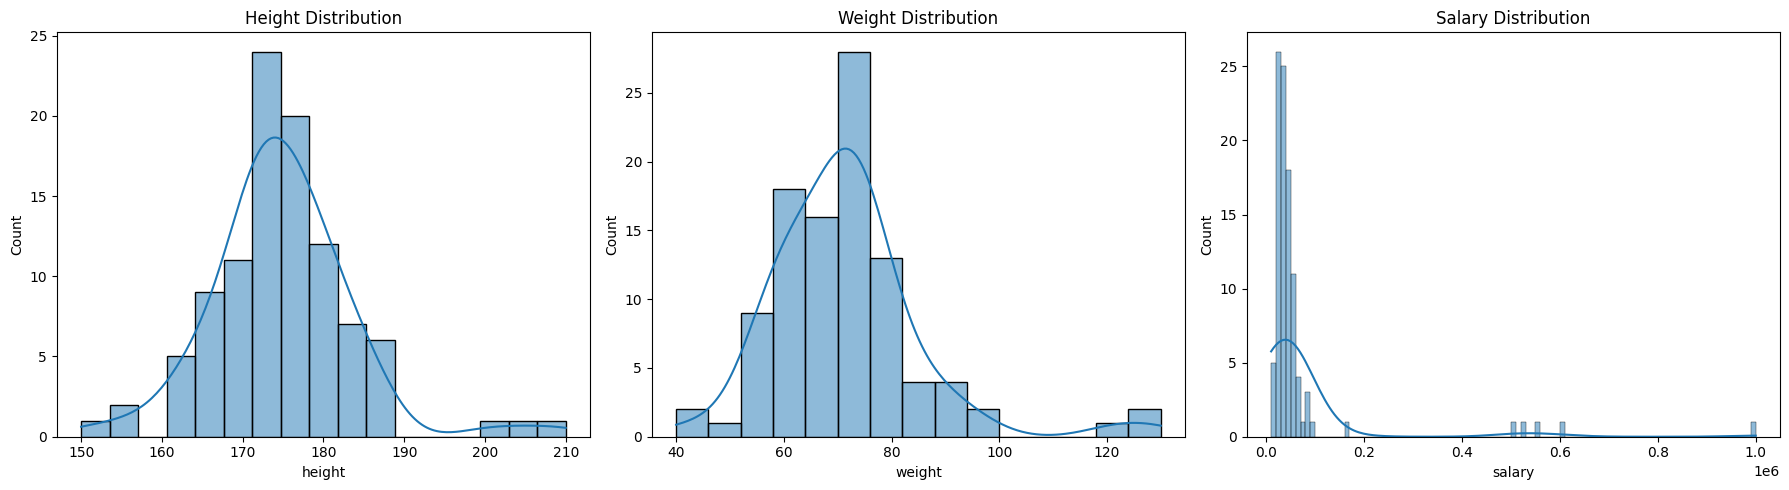

In [6]:
# Visualize distributions to identify potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['height'], kde=True)
plt.title('Height Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['weight'], kde=True)
plt.title('Weight Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['salary'], kde=True)
plt.title('Salary Distribution')

plt.tight_layout()
plt.show()

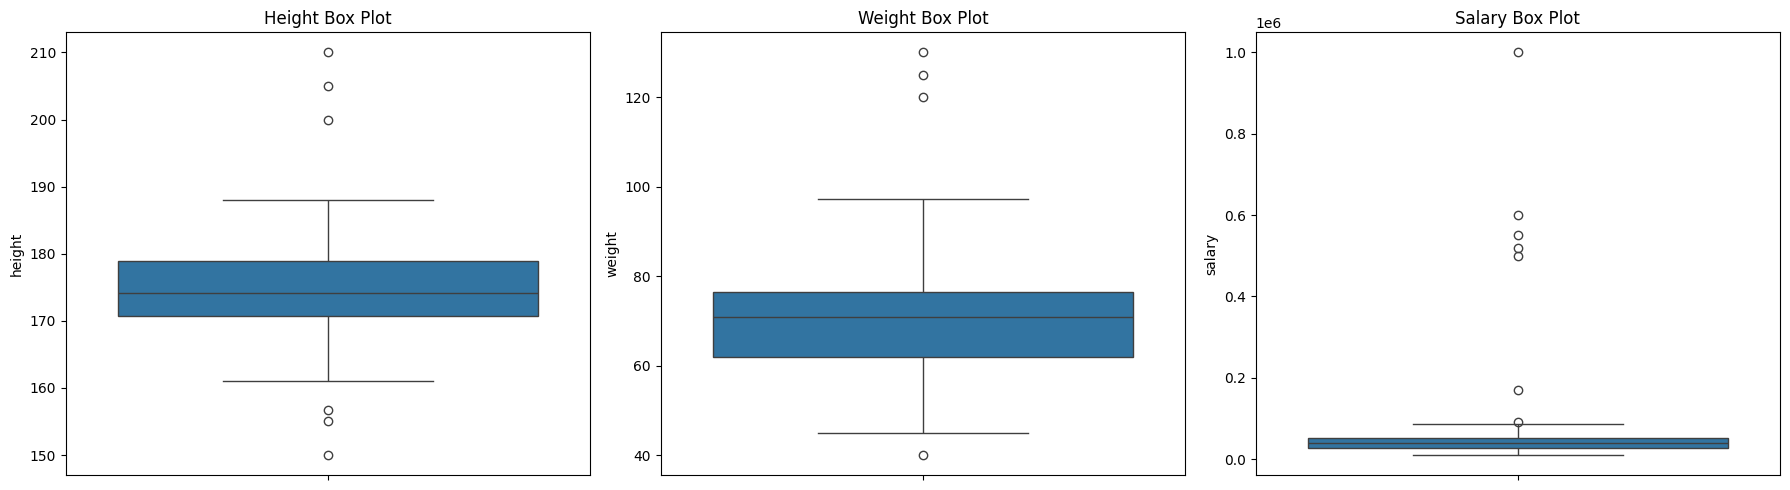

In [7]:
# Box plots to visualize potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['weight'])
plt.title('Weight Box Plot')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['salary'])
plt.title('Salary Box Plot')

plt.tight_layout()
plt.show()

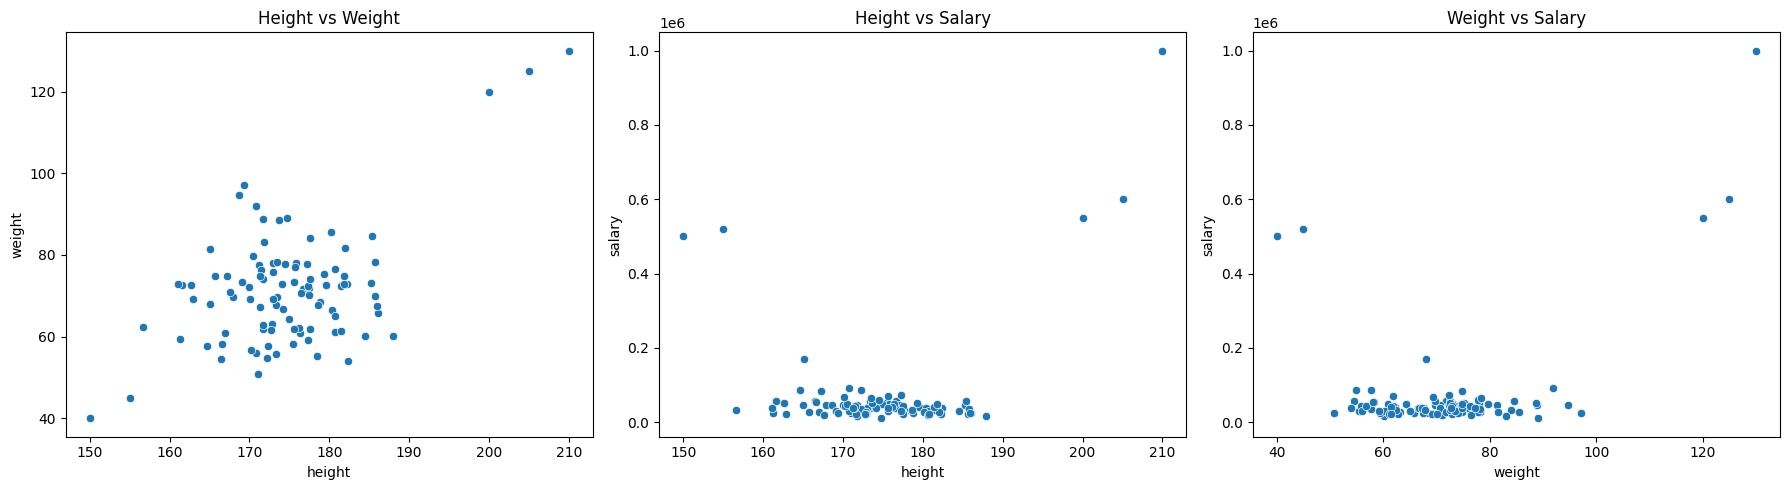

In [8]:
# Scatter plots to identify patterns and potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='height', y='weight', data=df)
plt.title('Height vs Weight')

plt.subplot(1, 3, 2)
sns.scatterplot(x='height', y='salary', data=df)
plt.title('Height vs Salary')

plt.subplot(1, 3, 3)
sns.scatterplot(x='weight', y='salary', data=df)
plt.title('Weight vs Salary')

plt.tight_layout()
plt.show()

In [9]:
# Define function for Z-score outlier detection
def detect_outliers_zscore(data, threshold=3):
    """
    Detect outliers using Z-score method
    Returns indices of outliers
    """
    z_scores = np.abs(stats.zscore(data))
    return np.where(z_scores > threshold)[0]


In [10]:
# Apply Z-score outlier detection
height_outliers_z = detect_outliers_zscore(df['height'])
weight_outliers_z = detect_outliers_zscore(df['weight'])
salary_outliers_z = detect_outliers_zscore(df['salary'])

print(f"Height outliers (Z-score): {len(height_outliers_z)} found at indices {height_outliers_z}")
print(f"Weight outliers (Z-score): {len(weight_outliers_z)} found at indices {weight_outliers_z}")
print(f"Salary outliers (Z-score): {len(salary_outliers_z)} found at indices {salary_outliers_z}")


Height outliers (Z-score): 2 found at indices [98 99]
Weight outliers (Z-score): 3 found at indices [97 98 99]
Salary outliers (Z-score): 5 found at indices [95 96 97 98 99]


In [11]:
# Define function for IQR outlier detection
def detect_outliers_iqr(data, factor=1.5):
    """
    Detect outliers using IQR method
    Returns indices of outliers
    """
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - (factor * iqr)
    upper_bound = q3 + (factor * iqr)
    return np.where((data < lower_bound) | (data > upper_bound))[0]


In [12]:
# Apply IQR outlier detection
height_outliers_iqr = detect_outliers_iqr(df['height'])
weight_outliers_iqr = detect_outliers_iqr(df['weight'])
salary_outliers_iqr = detect_outliers_iqr(df['salary'])

print(f"Height outliers (IQR): {len(height_outliers_iqr)} found at indices {height_outliers_iqr}")
print(f"Weight outliers (IQR): {len(weight_outliers_iqr)} found at indices {weight_outliers_iqr}")
print(f"Salary outliers (IQR): {len(salary_outliers_iqr)} found at indices {salary_outliers_iqr}")


Height outliers (IQR): 6 found at indices [74 95 96 97 98 99]
Weight outliers (IQR): 4 found at indices [95 97 98 99]
Salary outliers (IQR): 7 found at indices [19 30 95 96 97 98 99]


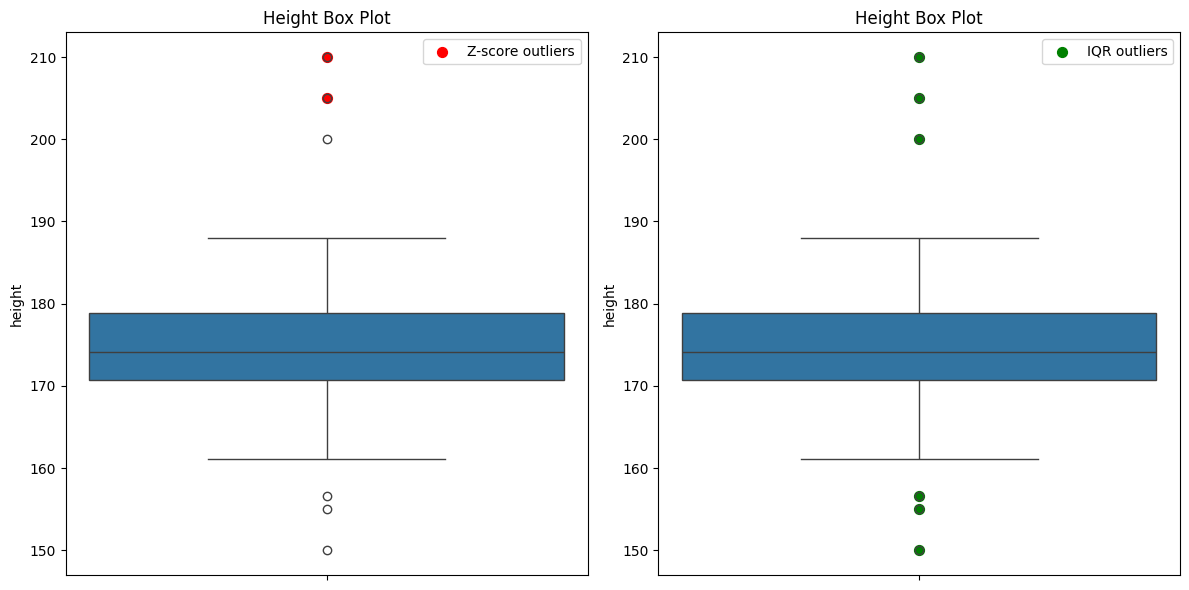

In [13]:
# Visualize the detected outliers for height using box plot with highlighted outliers
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')
plt.scatter(np.zeros_like(height_outliers_z), df['height'].iloc[height_outliers_z],
            color='red', s=50, label='Z-score outliers')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')
plt.scatter(np.zeros_like(height_outliers_iqr), df['height'].iloc[height_outliers_iqr],
            color='green', s=50, label='IQR outliers')
plt.legend()

plt.tight_layout()
plt.show()


In [14]:
# Examining the impact of outliers on statistical measures
print("With outliers:")
print(f"Height mean: {df['height'].mean():.2f}, std: {df['height'].std():.2f}")
print(f"Weight mean: {df['weight'].mean():.2f}, std: {df['weight'].std():.2f}")
print(f"Salary mean: {df['salary'].mean():.2f}, std: {df['salary'].std():.2f}")


With outliers:
Height mean: 174.80, std: 8.82
Weight mean: 71.40, std: 13.93
Salary mean: 70575.82, std: 138019.02


In [15]:
# Create copies without outliers (using IQR method)
df_no_outliers = df.copy()
all_outliers = list(set(height_outliers_iqr) | set(weight_outliers_iqr) | set(salary_outliers_iqr))
df_no_outliers = df_no_outliers.drop(all_outliers).reset_index(drop=True)

print("\nWithout outliers:")
print(f"Height mean: {df_no_outliers['height'].mean():.2f}, std: {df_no_outliers['height'].std():.2f}")
print(f"Weight mean: {df_no_outliers['weight'].mean():.2f}, std: {df_no_outliers['weight'].std():.2f}")
print(f"Salary mean: {df_no_outliers['salary'].mean():.2f}, std: {df_no_outliers['salary'].std():.2f}")



Without outliers:
Height mean: 174.65, std: 6.18
Weight mean: 70.19, std: 9.50
Salary mean: 39059.91, std: 15713.95


In [16]:
# Handling outliers using different approaches
# 1. Removal (already done above)
# 2. Capping (Winsorization)
def winsorize(data, limits=(0.05, 0.05)):
    """Apply winsorization to limit extreme values"""
    lower_limit = np.percentile(data, limits[0] * 100)
    upper_limit = np.percentile(data, 100 - limits[1] * 100)
    return np.clip(data, lower_limit, upper_limit)

df_winsorized = df.copy()
df_winsorized['height'] = winsorize(df['height'])
df_winsorized['weight'] = winsorize(df['weight'])
df_winsorized['salary'] = winsorize(df['salary'])


In [17]:
# 3. Log transformation (especially useful for skewed data like salary)
df_log = df.copy()
df_log['salary'] = np.log(df['salary'])


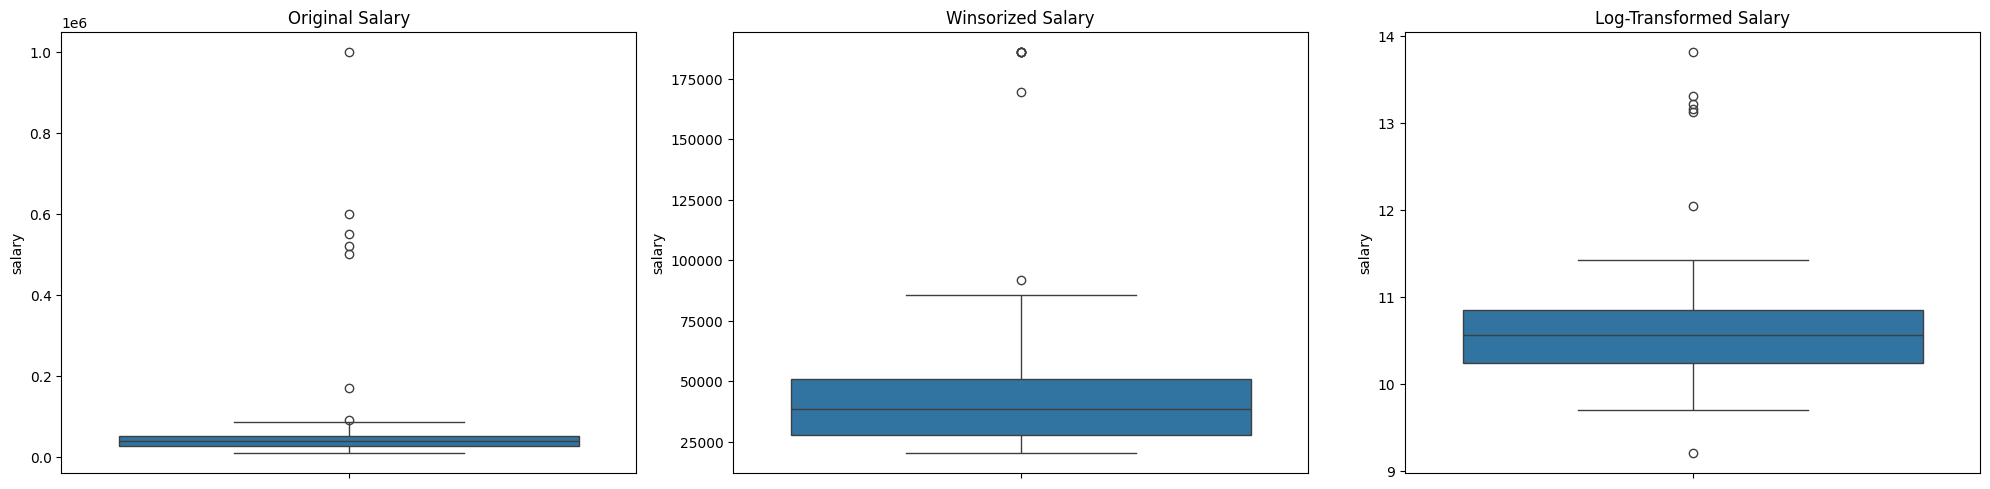

In [18]:
# Compare the distributions before and after transformation
plt.figure(figsize=(20, 5))

# Original distributions
plt.subplot(1, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

# After winsorization
plt.subplot(1, 3, 2)
sns.boxplot(y=df_winsorized['salary'])
plt.title('Winsorized Salary')

# After log transformation
plt.subplot(1, 3, 3)
sns.boxplot(y=df_log['salary'])
plt.title('Log-Transformed Salary')

plt.tight_layout()
plt.show()

In [19]:
# Feature associations and correlation analysis
# Calculate correlation matrix
corr_matrix = df.corr()


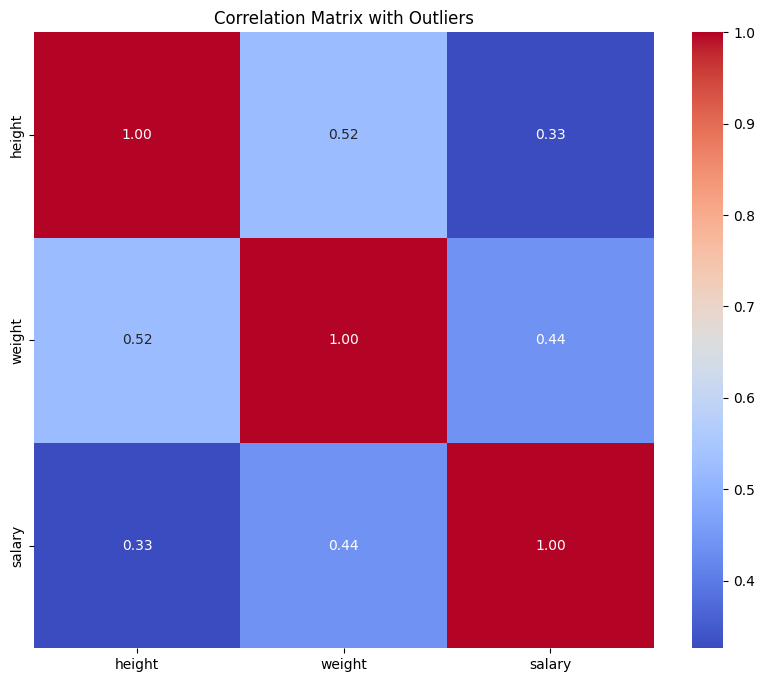

In [20]:
# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix with Outliers')
plt.show()


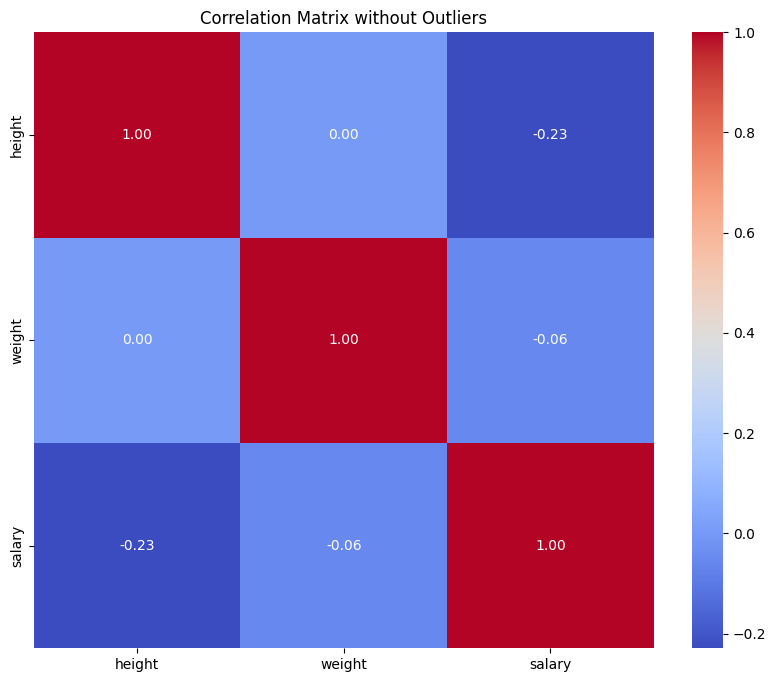

In [21]:
# Compare with correlation after removing outliers
corr_matrix_no_outliers = df_no_outliers.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_no_outliers, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix without Outliers')
plt.show()


In [22]:
# Create function to profile features and detect potential issues
def profile_feature(data, feature_name):
    """Create a basic profile of a numeric feature"""
    feature = data[feature_name]

    # Basic statistics
    stats_dict = {
        'Count': len(feature),
        'Mean': feature.mean(),
        'Median': feature.median(),
        'Std Dev': feature.std(),
        'Min': feature.min(),
        'Max': feature.max(),
        'Range': feature.max() - feature.min(),
        'IQR': np.percentile(feature, 75) - np.percentile(feature, 25),
        'Skewness': stats.skew(feature),
        'Kurtosis': stats.kurtosis(feature),
        'Missing Values': feature.isna().sum(),
        'Missing %': feature.isna().mean() * 100
    }

    # Z-score outliers
    z_outliers = detect_outliers_zscore(feature)
    stats_dict['Z-score Outliers'] = len(z_outliers)
    stats_dict['Z-score Outlier %'] = len(z_outliers) / len(feature) * 100

    # IQR outliers
    iqr_outliers = detect_outliers_iqr(feature)
    stats_dict['IQR Outliers'] = len(iqr_outliers)
    stats_dict['IQR Outlier %'] = len(iqr_outliers) / len(feature) * 100

    return pd.Series(stats_dict, name=feature_name)


In [23]:
# Apply feature profiling to the dataset
profile_results = pd.DataFrame([
    profile_feature(df, 'height'),
    profile_feature(df, 'weight'),
    profile_feature(df, 'salary')
])

# Display the feature profiles
profile_results


,Count,Mean,Median,Std Dev,Min,Max,Range,IQR,Skewness,Kurtosis,Missing Values,Missing %,Z-score Outliers,Z-score Outlier %,IQR Outliers,IQR Outlier %
height,100.0,174.802581,174.111306,8.824677,150.000000,210.0,60.000000,8.206793,0.802248,3.330725,0.0,0.0,2.0,2.0,6.0,6.0
weight,100.0,71.397280,70.841072,13.932214,40.000000,130.0,90.000000,14.390494,1.587588,4.962706,0.0,0.0,3.0,3.0,4.0,4.0
salary,100.0,70575.816571,38441.915870,138019.017873,9931.760814,1000000.0,990068.239186,23348.615150,4.740303,23.787349,0.0,0.0,5.0,5.0,7.0,7.0


In [36]:
# Fixed function for multivariate outlier detection
def detect_multivariate_outliers(data, method='mahalanobis', threshold=0.99):
    """
    Detect multivariate outliers using Mahalanobis distance
    Returns indices of outliers
    """
    if method == 'mahalanobis':
        # Calculate Mahalanobis distance
        x = data.values
        covariance_matrix = np.cov(x, rowvar=False)
        inv_covariance_matrix = np.linalg.inv(covariance_matrix)
        mean_vector = np.mean(x, axis=0)
        print(mean_vector)
        print('hello')

        # Implement mahalanobis distance manually
        mahalanobis_dist = []
        for i in range(x.shape[0]):
            x_i = x[i, :]
            # Calculate mahalanobis distance: (x-μ)ᵀΣ⁻¹(x-μ)
            diff = x_i - mean_vector
            mahal = diff.dot(inv_covariance_matrix).dot(diff.T)
            mahalanobis_dist.append(mahal)

        # Convert to array
        mahalanobis_dist = np.array(mahalanobis_dist)

        # Find threshold using chi-squared distribution
        threshold_value = stats.chi2.ppf(threshold, df=x.shape[1])

        # Return indices of outliers
        return np.where(mahalanobis_dist > threshold_value)[0]
    else:
        raise ValueError("Only 'mahalanobis' method is currently supported")


In [37]:
# Apply multivariate outlier detection
multivariate_outliers = detect_multivariate_outliers(df, threshold=0.95)
print(f"Multivariate outliers: {len(multivariate_outliers)} found at indices {multivariate_outliers}")


[  174.80258129    71.39728024 70575.81657143]
hello
Multivariate outliers: 6 found at indices [84 95 96 97 98 99]


<Figure size 1200x1000 with 0 Axes>

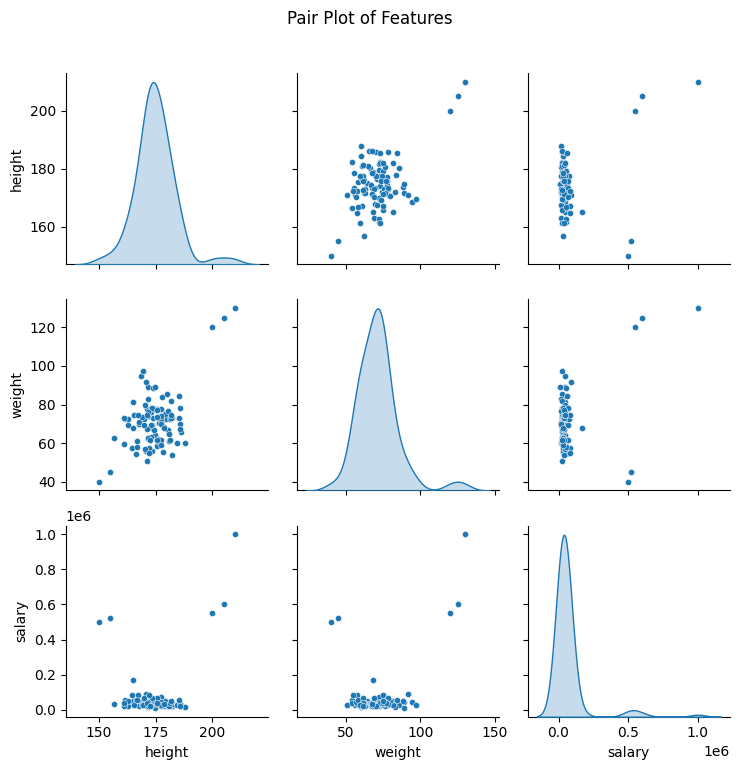

In [38]:
# Visualize the multivariate outliers in a pair plot
plt.figure(figsize=(12, 10))
sns.pairplot(df, diag_kind='kde', plot_kws={"s": 20})
plt.suptitle('Pair Plot of Features', y=1.02)
plt.tight_layout()
plt.show()

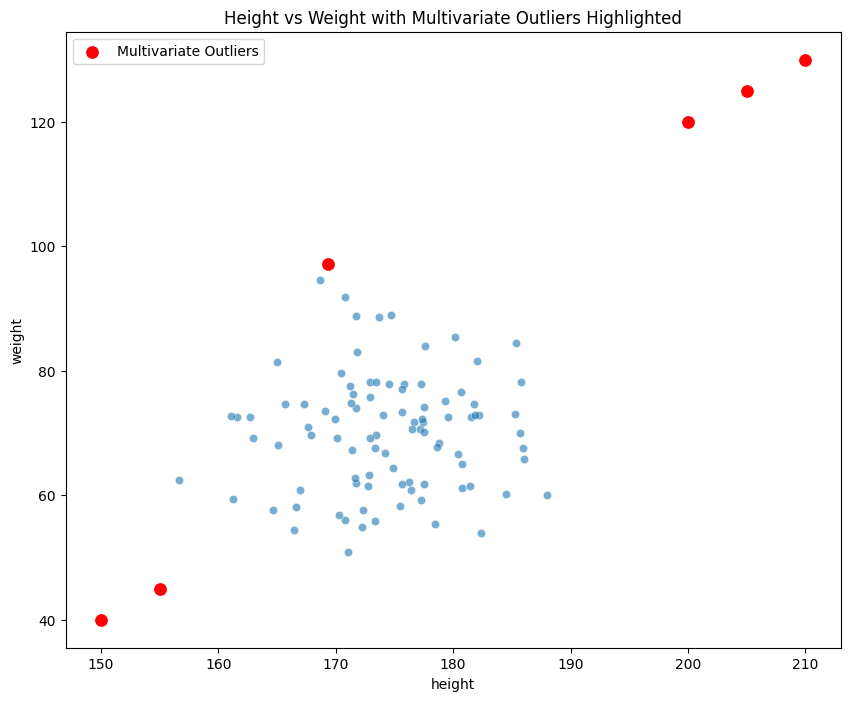

In [39]:
# Highlight the multivariate outliers in a scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='height', y='weight', data=df, alpha=0.6)
sns.scatterplot(x='height', y='weight', data=df.iloc[multivariate_outliers],
                color='red', s=100, label='Multivariate Outliers')
plt.title('Height vs Weight with Multivariate Outliers Highlighted')
plt.legend()
plt.show()


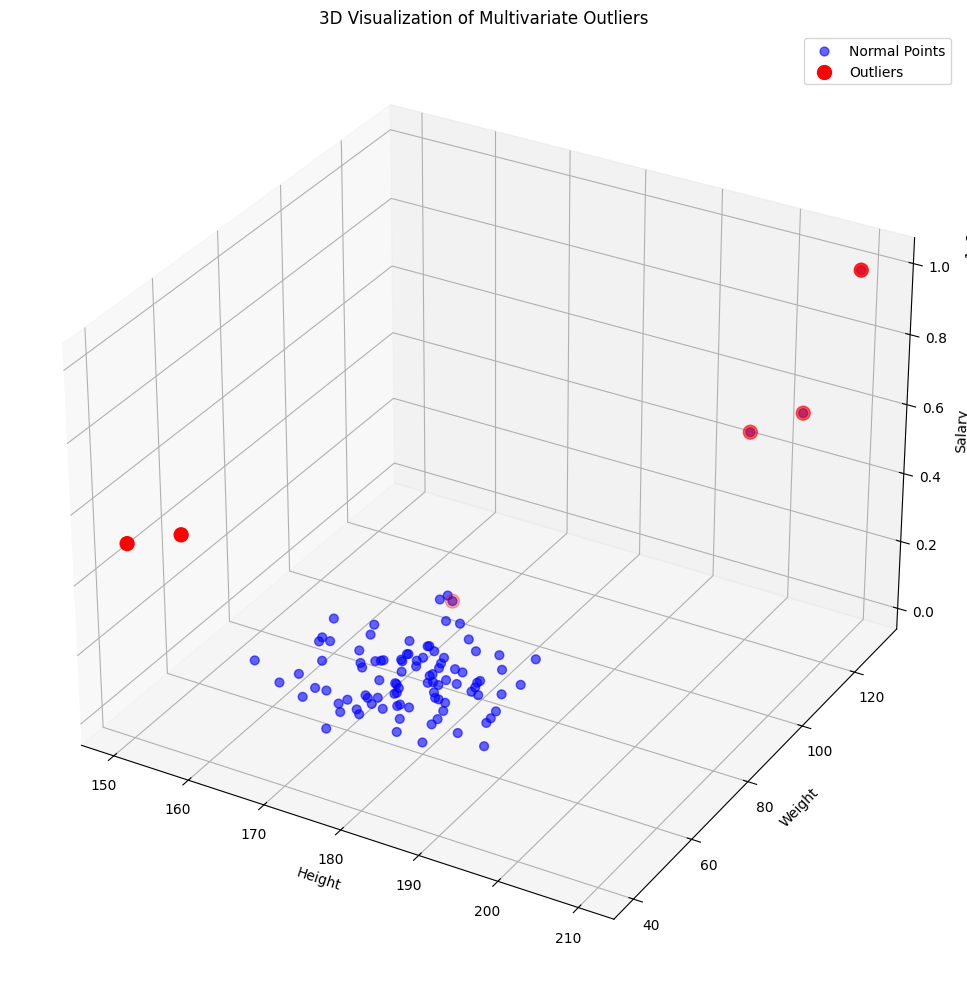

In [40]:
# 3D visualization of outliers
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Regular points
ax.scatter(df['height'], df['weight'], df['salary'], c='blue', s=40, alpha=0.6, label='Normal Points')
# Outliers
ax.scatter(df.iloc[multivariate_outliers]['height'], df.iloc[multivariate_outliers]['weight'],
           df.iloc[multivariate_outliers]['salary'], c='red', s=100, label='Outliers')

ax.set_xlabel('Height')
ax.set_ylabel('Weight')
ax.set_zlabel('Salary')
ax.set_title('3D Visualization of Multivariate Outliers')
plt.legend()
plt.tight_layout()
plt.show()


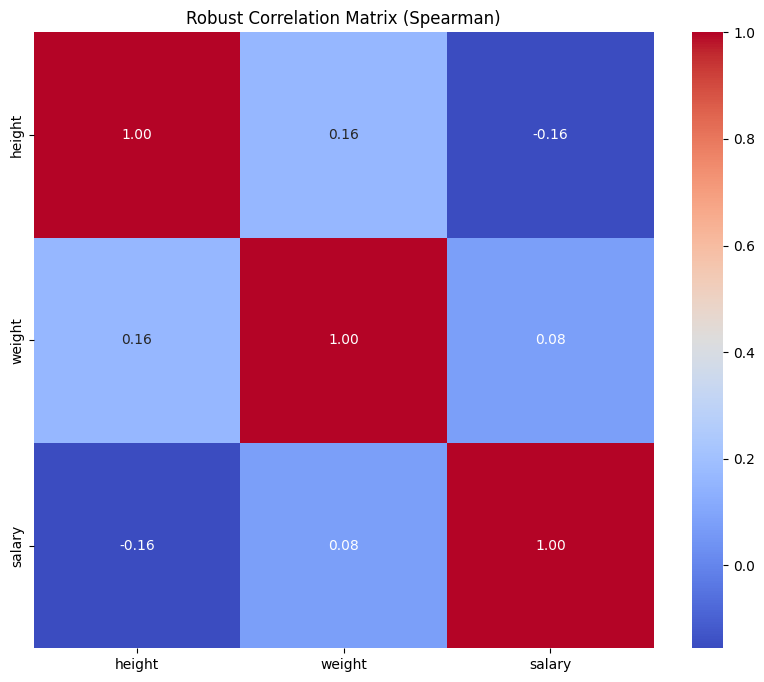

In [41]:
# Simple robust correlation calculation using Spearman instead of Pearson
robust_corr = df.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(robust_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Robust Correlation Matrix (Spearman)')
plt.show()


In [42]:
# Apply different scaling methods before and after outlier treatment
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

In [43]:
# Original data
scaler_standard = StandardScaler()
df_scaled_standard = pd.DataFrame(
    scaler_standard.fit_transform(df),
    columns=df.columns
)


In [44]:
# Using robust scaler which is less influenced by outliers
scaler_robust = RobustScaler()
df_scaled_robust = pd.DataFrame(
    scaler_robust.fit_transform(df),
    columns=df.columns
)

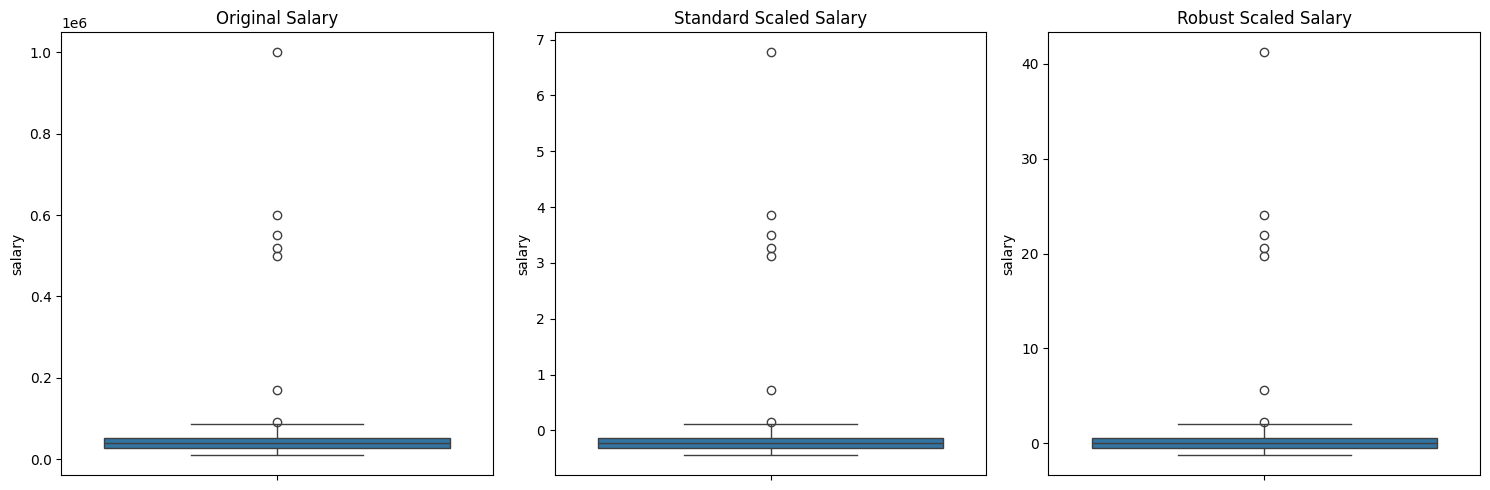

In [45]:
# Compare the scaled distributions
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_scaled_standard['salary'])
plt.title('Standard Scaled Salary')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_scaled_robust['salary'])
plt.title('Robust Scaled Salary')

plt.tight_layout()
plt.show()


In [46]:
# Demonstrate impact of outliers on linear regression
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [47]:
# Create dataset with outlier
x = np.array(range(20)).reshape(-1, 1)
y = 2*x.ravel() + 5 + np.random.normal(0, 1, 20)
y[19] = 80  # add outlier

plt.figure(figsize=(12, 6))


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'With Outlier: y = 2.57x + 1.40')

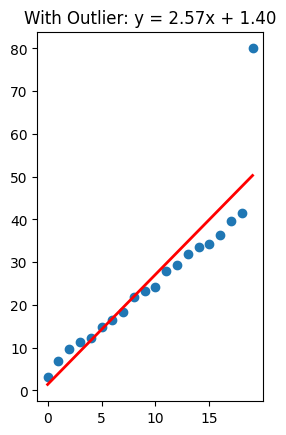

In [48]:
# Plot with outlier
plt.subplot(1, 2, 1)
plt.scatter(x, y)
model = LinearRegression().fit(x, y)
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'With Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')


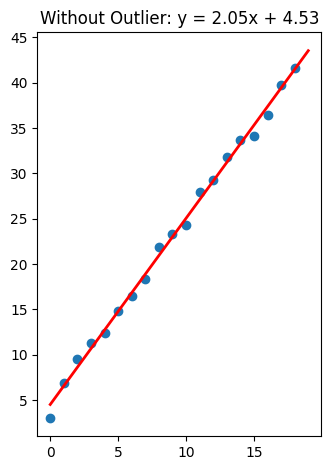

In [49]:
# Plot without outlier
plt.subplot(1, 2, 2)
plt.scatter(x[:-1], y[:-1])
model = LinearRegression().fit(x[:-1], y[:-1])
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'Without Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')

plt.tight_layout()
plt.show()

# Interactive Coding Exercise: Advanced Outlier Detection & Analysis


In [ ]:
# ----------------------------------------------------------------
# In this exercise, you'll work with a real-world dataset to:
# 1. Apply outlier detection techniques
# 2. Compare methods and their impact
# 3. Implement a custom outlier detection workflow

In [50]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the California housing dataset instead of Boston
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Create a DataFrame with all features plus the target
df = X.copy()
df['MedHouseVal'] = y  # The target is median house value

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFeature names:", list(X.columns))
print("\nFirst 5 rows:")
df.head()

Dataset shape: (20640, 9)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


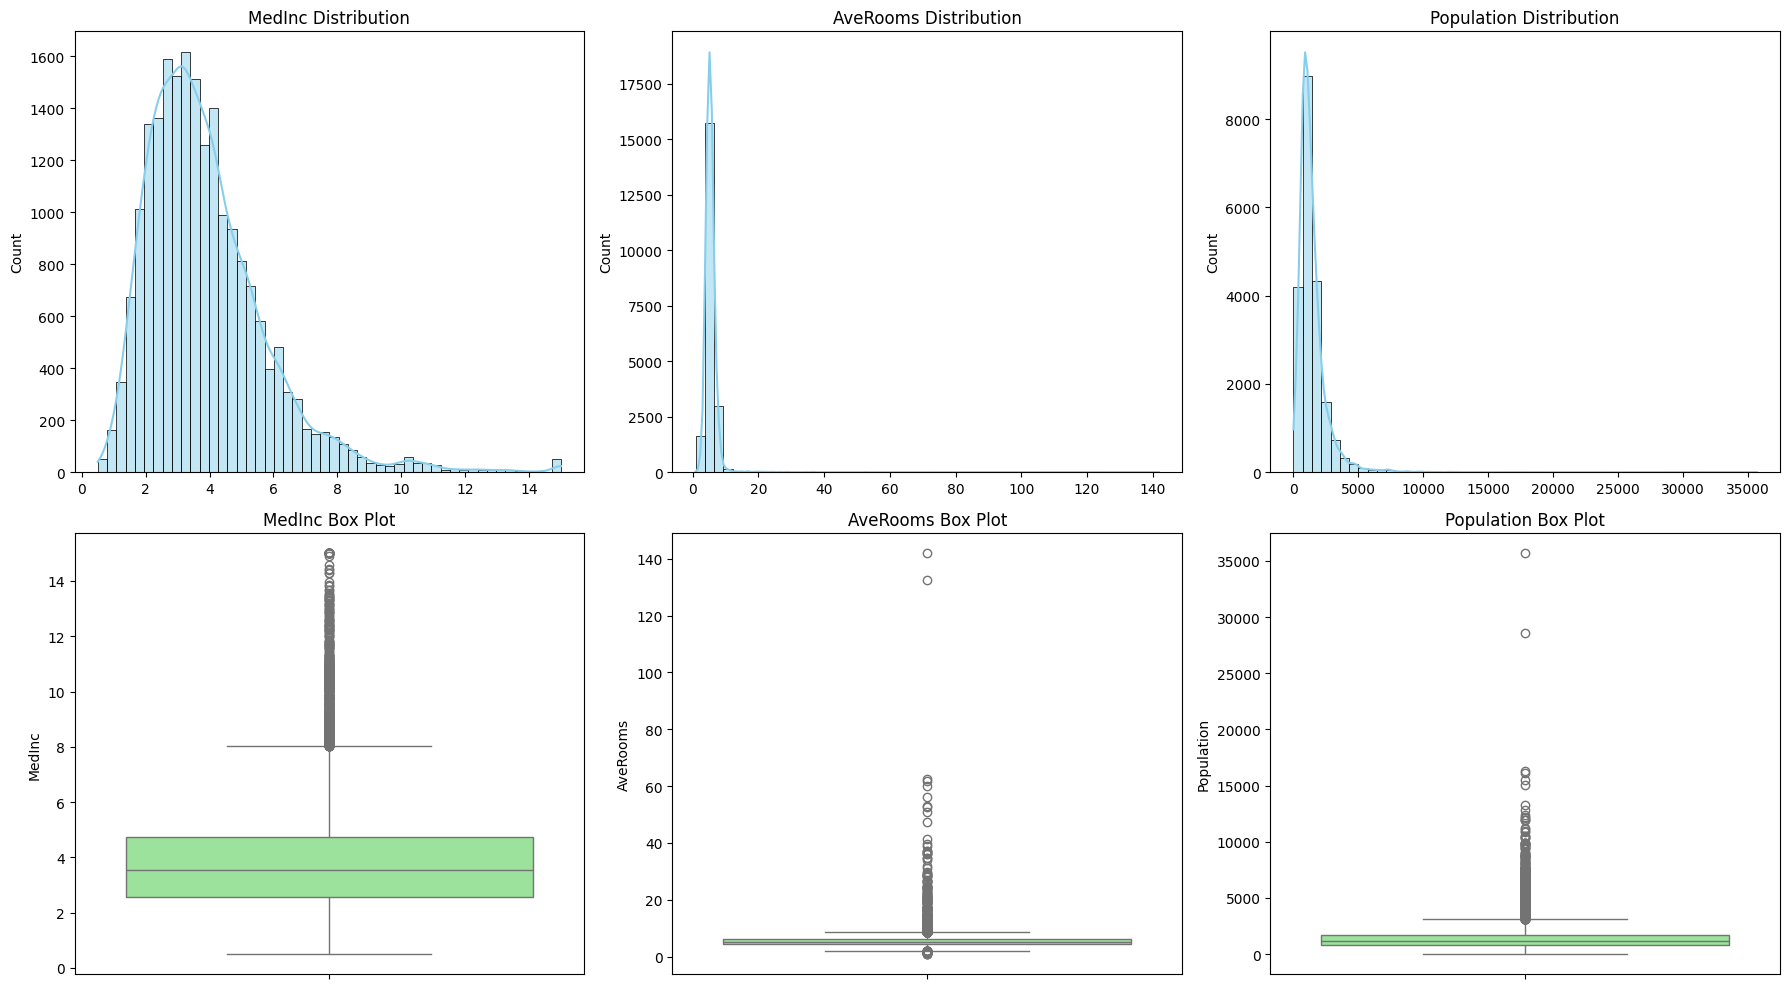

In [51]:
# EXERCISE 1: Exploratory Data Analysis for Outlier Detection
# -----------------------------------------------------------
# TODO: Create histograms and boxplots for at least 3 features to visually identify outliers
# Hint: Use subplot to organize multiple plots

features_to_check = ['MedInc', 'AveRooms', 'Population']

# Create a figure with 2 rows (Histograms top, Boxplots bottom) and 3 columns
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))

for i, feature in enumerate(features_to_check):
    # Top Row: Histograms to see the overall distribution shape
    sns.histplot(df[feature], kde=True, bins=50, ax=axes[0, i], color='skyblue')
    axes[0, i].set_title(f'{feature} Distribution')
    axes[0, i].set_xlabel('') # Clean up x-label for the top row
    
    # Bottom Row: Boxplots to visually isolate the extreme outliers
    sns.boxplot(y=df[feature], ax=axes[1, i], color='lightgreen')
    axes[1, i].set_title(f'{feature} Box Plot')
    axes[1, i].set_ylabel(feature)

# Adjust layout so titles and labels don't overlap
plt.tight_layout()
plt.show()

In [54]:
# EXERCISE 2: Implement Multiple Outlier Detection Methods
# -------------------------------------------------------
# TODO: Implement both Z-score and IQR outlier detection for the LSTAT feature
# LSTAT: % lower status of the population
#I am using this instead of LSTAT because it was deprecated from sklearn
target_feature = 'MedInc'
z_scores = np.abs(stats.zscore(df[target_feature]))

# Identify indices where Z-score is greater than 3
MedInc_outliers_z = np.where(z_scores > 3)[0]


# --- 2. IQR Method ---
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
q1 = df[target_feature].quantile(0.25)
q3 = df[target_feature].quantile(0.75)
iqr = q3 - q1

# Define the lower and upper bounds
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

# Identify indices where values fall outside the bounds
MedInc_outliers_iqr = np.where(
    (df[target_feature] < lower_bound) | (df[target_feature] > upper_bound)
)[0]


# --- Print Results ---
print(f"Feature analyzed: {target_feature}")
print(f"Number of Z-score outliers detected: {len(MedInc_outliers_z)}")
print(f"Number of IQR outliers detected: {len(MedInc_outliers_iqr)}")

Feature analyzed: MedInc
Number of Z-score outliers detected: 345
Number of IQR outliers detected: 681


In [53]:
# EXERCISE 3: Advanced Outlier Detection - Isolation Forest
# --------------------------------------------------------
# TODO: Implement the Isolation Forest algorithm to detect outliers in the dataset
# Use contamination=0.05 (assuming 5% of data points are outliers)
# Return a binary mask where -1 represents outliers

iso_forest = IsolationForest(contamination=0.05, random_state=42)

outlier_predictions = iso_forest.fit_predict(X)

outlier_mask = (outlier_predictions == -1)

isolation_outliers = np.where(outlier_mask)[0]

print(f"Total data points analyzed: {len(X)}")
print(f"Number of outliers detected (5% contamination): {len(isolation_outliers)}")

Total data points analyzed: 20640
Number of outliers detected (5% contamination): 1032


In [55]:
# EXERCISE 4: Compare the Impact of Outliers on Linear Regression
# --------------------------------------------------------------
# TODO:
# 1. Create a simple linear regression model using 'LSTAT' to predict 'PRICE'
# 2. Create 3 versions:
#    a. With all data
#    b. After removing Z-score outliers
#    c. After removing Isolation Forest outliers
# 3. Compare the model performance metrics (r2_score) and coefficients


def evaluate_regression(X, y, description):
    # Initialize and fit the model
    model = LinearRegression()
    model.fit(X, y)
    
    # Generate predictions
    predictions = model.predict(X)
    
    # Calculate R-squared score
    r2 = r2_score(y, predictions)
    
    # Print the results
    print(f"--- {description} ---")
    print(f"R-squared (R2) Score: {r2:.4f}")
    print(f"Coefficient (Slope): {model.coef_[0]:.4f}")
    print(f"Data points used: {len(X)}\n")

# a. Version 1: With all raw data
X_all = df[['MedInc']]
y_all = df['MedHouseVal']
evaluate_regression(X_all, y_all, "Version A: All Data")

# b. Version 2: After removing Z-score outliers (using the variable from Ex 2)
# The .drop() function removes rows based on their index numbers
X_z_clean = df[['MedInc']].drop(index=MedInc_outliers_z)
y_z_clean = df['MedHouseVal'].drop(index=MedInc_outliers_z)
evaluate_regression(X_z_clean, y_z_clean, "Version B: Z-score Outliers Removed")

# c. Version 3: After removing Isolation Forest outliers (using the variable from Ex 3)
X_iso_clean = df[['MedInc']].drop(index=isolation_outliers)
y_iso_clean = df['MedHouseVal'].drop(index=isolation_outliers)
evaluate_regression(X_iso_clean, y_iso_clean, "Version C: Isolation Forest Outliers Removed")


--- Version A: All Data ---
R-squared (R2) Score: 0.4734
Coefficient (Slope): 0.4179
Data points used: 20640

--- Version B: Z-score Outliers Removed ---
R-squared (R2) Score: 0.4321
Coefficient (Slope): 0.4521
Data points used: 20295

--- Version C: Isolation Forest Outliers Removed ---
R-squared (R2) Score: 0.4645
Coefficient (Slope): 0.4459
Data points used: 19608



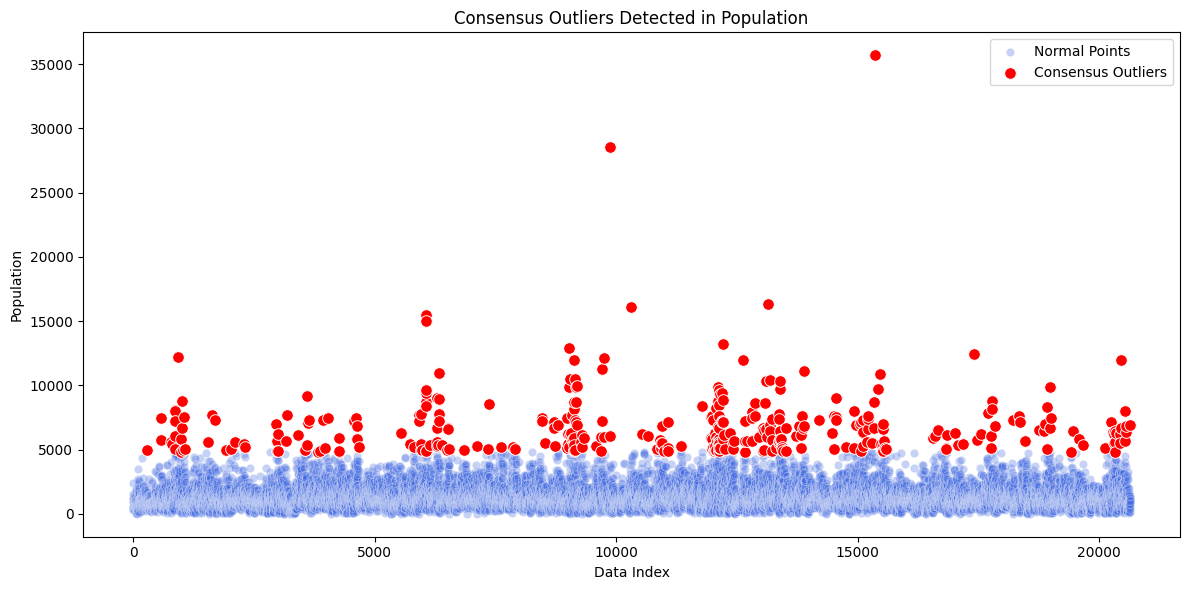

Total rows analyzed: 20640
Number of consensus outliers found in 'Population': 342


In [56]:
# EXERCISE 5: Create Your Own Outlier Detection Workflow
# -----------------------------------------------------
# TODO: Create a custom outlier detection function that combines multiple methods
# It should:
# 1. Take a dataframe and column name as input
# 2. Apply at least 2 different outlier detection methods (of your choice)
# 3. Return the indices of consensus outliers (detected by both methods)
# 4. Include a visualization of the outliers

def custom_consensus_outliers(data, column_name):
    
    # 1. Z-Score Method
    z_scores = np.abs(stats.zscore(data[column_name]))
    z_idx = np.where(z_scores > 3)[0]
    
    # 2. IQR Method
    q1 = data[column_name].quantile(0.25)
    q3 = data[column_name].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    
    iqr_idx = np.where((data[column_name] < lower_bound) | (data[column_name] > upper_bound))[0]
    
    # 3. Consensus (Find intersection of both index arrays)
    consensus_idx = np.intersect1d(z_idx, iqr_idx)
    
    # 4. Visualization
    plt.figure(figsize=(12, 6))
    
    # Plot all normal data points
    sns.scatterplot(x=data.index, y=data[column_name], alpha=0.3, label='Normal Points', color='royalblue')
    
    # Overlay the consensus outliers in bold red
    sns.scatterplot(x=consensus_idx, y=data[column_name].iloc[consensus_idx], 
                    color='red', s=70, label='Consensus Outliers')
    
    plt.title(f'Consensus Outliers Detected in {column_name}')
    plt.xlabel('Data Index')
    plt.ylabel(column_name)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return consensus_idx

# Apply the workflow to a highly skewed feature like 'Population'
population_outliers = custom_consensus_outliers(df, 'Population')

print(f"Total rows analyzed: {len(df)}")
print(f"Number of consensus outliers found in 'Population': {len(population_outliers)}")

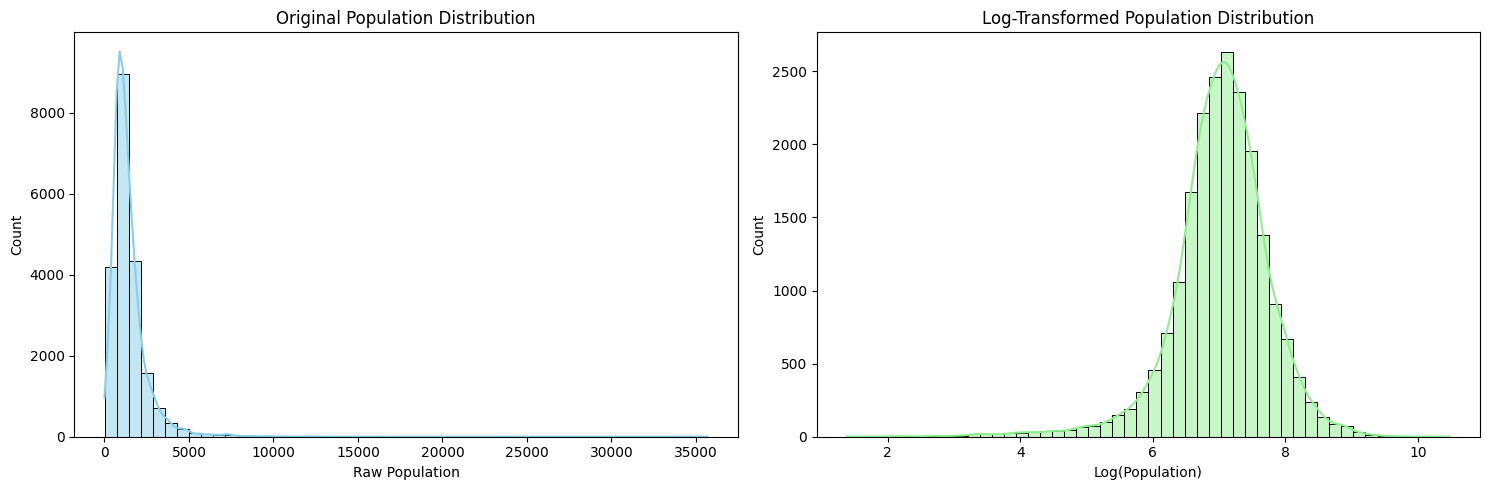

In [57]:
# EXERCISE 6: Robust Feature Engineering with Outliers
# ---------------------------------------------------
# TODO: Create a new feature that is more robust to outliers
# Suggestions:
# - Use log transformation
# - Use binning/discretization
# - Create a ratio or interaction feature
# Compare the distribution before and after your transformation

df['Log_Population'] = np.log1p(df['Population'])

df['Bedrms_per_Room'] = df['AveBedrms'] / df['AveRooms']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Original highly skewed Population
sns.histplot(df['Population'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Original Population Distribution')
axes[0].set_xlabel('Raw Population')

# Plot 2: Log-transformed Population
sns.histplot(df['Log_Population'], bins=50, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Log-Transformed Population Distribution')
axes[1].set_xlabel('Log(Population)')

plt.tight_layout()
plt.show()

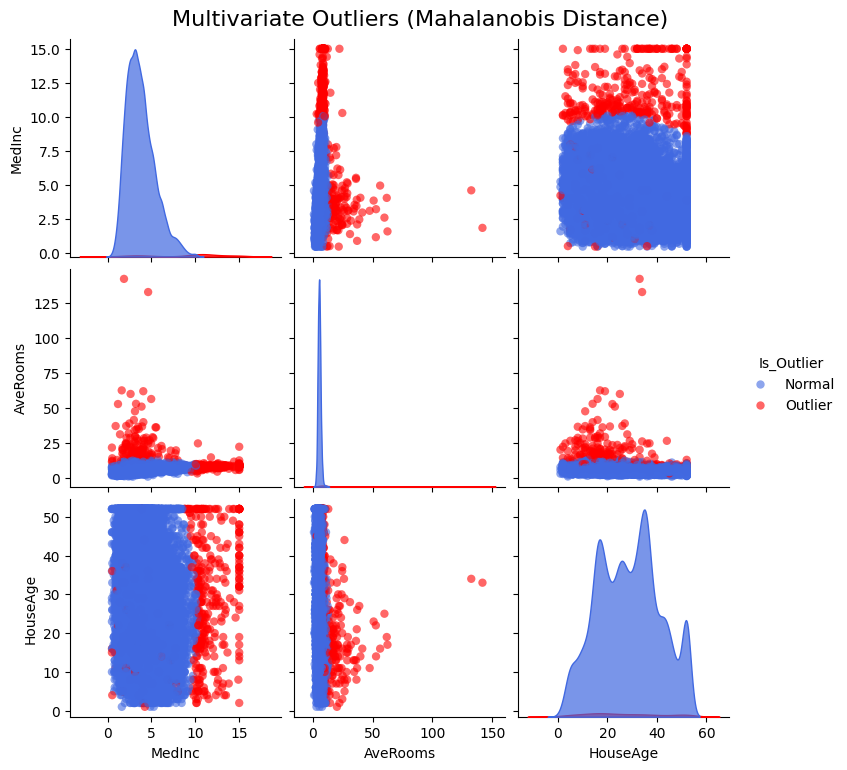

Features analyzed: ['MedInc', 'AveRooms', 'HouseAge']
Chi-Squared Threshold (99%): 11.34
Number of multivariate outliers detected: 448


In [58]:
# EXERCISE 7: BONUS CHALLENGE - Multivariate Outlier Detection
# ------------------------------------------------------------
# TODO: Implement a multivariate outlier detection method using Mahalanobis distance
# Calculate the distance for each point and identify outliers using a chi-squared threshold
# Visualize the results using a scatter plot matrix highlighting the outliers

features = ['MedInc', 'AveRooms', 'HouseAge']
X_multi = df[features].values

# 2. Calculate the Mean Vector (μ) and Inverse Covariance Matrix (Σ⁻¹)
mean_vector = np.mean(X_multi, axis=0)
covariance_matrix = np.cov(X_multi, rowvar=False)
inv_covariance_matrix = np.linalg.inv(covariance_matrix)

# 3. Calculate Mahalanobis Distance for each point
# Remembering our first lesson: Do NOT use np.sqrt()!
mahalanobis_dist = []
for i in range(X_multi.shape[0]):
    x_i = X_multi[i, :]
    diff = x_i - mean_vector
    # Calculate D-squared
    d2 = diff.dot(inv_covariance_matrix).dot(diff.T) 
    mahalanobis_dist.append(d2)

mahalanobis_dist = np.array(mahalanobis_dist)

# 4. Set the Chi-Squared Threshold
# df = degrees of freedom (number of features). We'll use the 99th percentile.
threshold = stats.chi2.ppf(0.99, df=len(features))

# 5. Identify the Outliers
outlier_indices = np.where(mahalanobis_dist > threshold)[0]

# 6. Visualization Setup
# Create a fresh DataFrame specifically for plotting
plot_df = df[features].copy()
plot_df['Is_Outlier'] = 'Normal'
# Update the label for the detected outlier rows
plot_df.iloc[outlier_indices, plot_df.columns.get_loc('Is_Outlier')] = 'Outlier'

# Create the scatter plot matrix
sns.pairplot(
    plot_df, 
    hue='Is_Outlier', 
    palette={'Normal': 'royalblue', 'Outlier': 'red'},
    plot_kws={'alpha': 0.6, 'edgecolor': 'none'},
    diag_kws={'alpha': 0.7}
)
plt.suptitle('Multivariate Outliers (Mahalanobis Distance)', y=1.02, fontsize=16)
plt.show()

# Print out the final stats
print(f"Features analyzed: {features}")
print(f"Chi-Squared Threshold (99%): {threshold:.2f}")
print(f"Number of multivariate outliers detected: {len(outlier_indices)}")
